In [1]:
import phoebe
from phoebe.features import ComponentFeature
from phoebe.parameters import FloatParameter, ParameterSet, constraint
from astropy import units as u
import numpy as np

b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0,1,101))
b.set_value('irrad_method', 'none')
b.set_value_all('distortion_method', 'sphere')

b.run_compute(model='no_features')

class SinusoidalIntensities(ComponentFeature):
    @classmethod
    def create_feature_parameters(self, feature, **kwargs):
        params = []
        params += [FloatParameter(qualifier='amplitude',
                                  latexfmt=r'A_\mathrm{{ {feature} }}',
                                  value=kwargs.get('amplitude', 0.1),
                                  default_unit=u.dimensionless_unscaled,
                                  description='Relative amplitude of the sinusoidal intensities contribution')]
        params += [FloatParameter(qualifier='period',
                                  latexfmt=r'P_\mathrm{{ {feature} }}',
                                  value=kwargs.get('period', 1.0),
                                  default_unit=u.d,
                                  description='Period of the sinusoidal intensities contribution')]
        params += [FloatParameter(qualifier='freq',
                                  latexfmt=r'f_\mathrm{{ {feature} }}',
                                  value=kwargs.get('freq', 2*np.pi/3.0),
                                  default_unit=u.rad/u.d, advanced=True,
                                  description='Frequency of the sinusoidal intensities contribution')]

        constraints = [(constraint.freq, feature, 'feature')]

        return ParameterSet(params), constraints
    
    @classmethod
    def parse_bundle(cls, b, feature):
        t0 = b.get_value(qualifier='t0', context='system', unit=u.d, **_skip_filter_checks)
        feature_dict =  cls.parse_from_feature_ps(b, feature,
                                                  ['amplitude',
                                                  {'qualifier': 'period', 'unit': 'd'}])
        return dict(t0=t0, **feature_dict)

    def modify_intensities(self, abs_normal_intensities, abs_intensities,
                           mus, pblum_scale, extinct_factors, boost_factors,
                           roche_coords, s=[0., 0., 1.], t=None):
        import numpy as np
        f = 1 + self.kwargs['amplitude'] * np.sin(2 * np.pi * (t - self.kwargs['t0']) / self.kwargs['period'])
        return abs_normal_intensities*f, abs_intensities*f

b.add_feature(SinusoidalIntensities, component='primary', period=0.2, amplitude=0.2, feature='sinusoidal_intensities')
b.add_dataset('mesh', compute_phases=phoebe.linspace(0,1,51), columns='intensities*')
b.run_compute(model='with_sin_intens')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 146.14it/s]


<ParameterSet: 515 parameters | kinds: mesh, lc>

In [3]:
b.plot(kind='mesh', animate=True, fc='intensities@lc01', ec='face', save='./mesh_with_sin_intens.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


(<autofig.figure.Figure | 1 axes | 102 call(s)>,
 <matplotlib.animation.FuncAnimation at 0x16db03490>)

![mesh animation](mesh_with_sin_intens.gif)

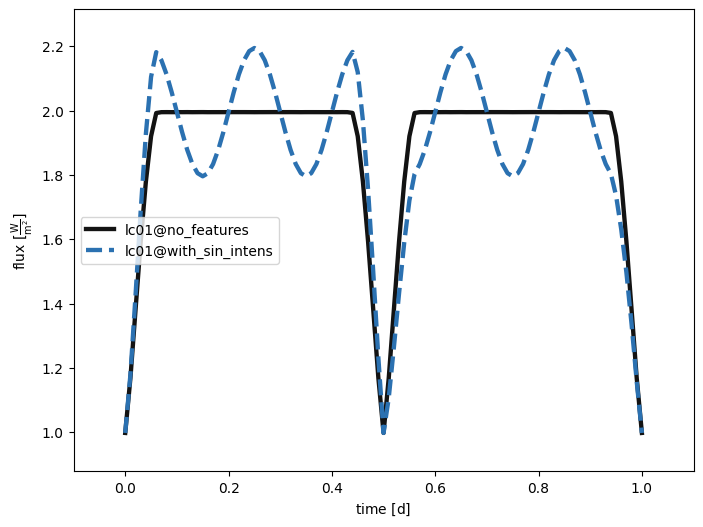

In [6]:
_ = b.plot(kind='lc', show=True, legend=True)